In [3]:
import requests
import pandas as pd
import numpy as np
import re
import time
import copy
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model     import Ridge, Lasso, ElasticNet
from sklearn.ensemble         import (RandomForestRegressor,
                                      GradientBoostingRegressor,
                                      ExtraTreesRegressor)
from sklearn.neighbors        import KNeighborsRegressor
from sklearn.preprocessing    import RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics          import (r2_score, mean_absolute_error,
                                      mean_squared_error)
from sklearn.model_selection  import TimeSeriesSplit
from xgboost                  import XGBRegressor
from collections              import Counter

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠ optuna not installed — run: pip install optuna")

print("✅ All imports successful")


⚠ optuna not installed — run: pip install optuna
✅ All imports successful


In [4]:
API_KEY  = "8bc7bd2c2dd27e1dd1a73d9191dcd67ad03a82822d3f0484b3c156ffdb04a26a"
BASE_URL = "http://44.201.93.152"
headers  = {"X-API-Key": API_KEY}

ALL_COMPANIES = [
    # Sugar (7)
    "AL NOOR SUGAR MILLS", "BABA FARID SUGAR MILLS",
    "Chashma Sugar", "Jauharabad Sugar Mills Limited",
    "SHAHTAJ LIMITED", "Tandlianwala Sugar Mills Limited",
    "Mehran Sugar Mills",
    # Paper (2)
    "Century Paper & Board Mill", "FEROZE 1888",
    # Auto (3)
    "Hino Motors", "PAK SUZUKI", "Ghandhara Nissan",
    # Textile (7)
    "Nishat Mills", "MASOOD TEXTILE MILLS", "Nishat (Chun.) Ltd.",
    "DIN TEXTILE MILLS LTD", "GADOON TEXTILE",
    "Blessed Textile", "Elahi Cotton",
    # Engineering (3)
    "DIAMOND INDUSTRIES", "PAK Electron Limited",
    "Thal Industries Corporation Limited",
    # Cement (8)
    "Safe Mix Concrete Limited", "LUCKY CEMENT", "bestway cement",
    "GHARIBWAL CEMENT", "POWER CEMENT LIMITED",
    "THATTA CEMENT", "Cherat Cement", "DADABHOY CEMENT INDUSTRIES",
    # Glass (1)
    "TARIQ GLASS INDUSTRIES LTD",
    # Oil/Gas (8)
    "MARI PETROLEUM", "Oil & Gas Dev.", "Hub Power Co",
    "PSO", "Shell Pakistan", "Attock Refinery",
    "KAPCO", "Ghani Gases Ltd",
    # Pharma/Chemical (9)
    "ITTEHAD CHEM", "BERGER PAINTS", "Highnoon", "Otsuka Pak",
    "Nimir  Ltd.", "Sitara Peroxide", "Leiner Pak Gelatine",
    "Ferozsons Labortaries", "Bawany Air Products",
    # Engg/Steel (8)
    "PAKISTAN CABLES", "INTERNATIONAL INDUSTRIES",
    "BOLAN CASTING", "AISHA STEEL MILL", "INTER STEEL LTD",
    "Exide Pakistan Ltd", "EMCO Industries", "Gammon Pak",
    # FMCG (8)
    "COLGATE PALMOLIVE", "RAFHAN MAIZE", "Murree Brewery",
    "Shield Corporation Limited", "KHYBER TOBACCO COMPANY LIMITED",
    "BATA PAKISTAN", "Gillette Pakistan Ltd.", "SERVICE IND.LTD",
    # Healthcare (2)
    "SHIFA HOSPITAL", "IBL Healthcare Ltd",
    # Logistics (2)
    "Pakistan International Container", "PAK INTERnationAL BULK TERMINAL",
    # Tech (3)
    "NETSOL technologies", "Pak Datacom", "P.T.C.L",
    # Other (1)
    "Engro Corp",
]

SECTOR_MAP = {
    "AL NOOR SUGAR MILLS": "Sugar", "BABA FARID SUGAR MILLS": "Sugar",
    "Chashma Sugar": "Sugar", "Jauharabad Sugar Mills Limited": "Sugar",
    "SHAHTAJ LIMITED": "Sugar", "Tandlianwala Sugar Mills Limited": "Sugar",
    "Mehran Sugar Mills": "Sugar",
    "Century Paper & Board Mill": "Paper", "FEROZE 1888": "Paper",
    "Hino Motors": "Auto", "PAK SUZUKI": "Auto", "Ghandhara Nissan": "Auto",
    "Nishat Mills": "Textile", "MASOOD TEXTILE MILLS": "Textile",
    "Nishat (Chun.) Ltd.": "Textile", "DIN TEXTILE MILLS LTD": "Textile",
    "GADOON TEXTILE": "Textile", "Blessed Textile": "Textile",
    "Elahi Cotton": "Textile",
    "DIAMOND INDUSTRIES": "Engineering", "PAK Electron Limited": "Engineering",
    "Thal Industries Corporation Limited": "Engineering",
    "Safe Mix Concrete Limited": "Cement", "LUCKY CEMENT": "Cement",
    "bestway cement": "Cement", "GHARIBWAL CEMENT": "Cement",
    "POWER CEMENT LIMITED": "Cement", "THATTA CEMENT": "Cement",
    "Cherat Cement": "Cement", "DADABHOY CEMENT INDUSTRIES": "Cement",
    "TARIQ GLASS INDUSTRIES LTD": "Glass",
    "MARI PETROLEUM": "Oil/Gas", "Oil & Gas Dev.": "Oil/Gas",
    "Hub Power Co": "Oil/Gas", "PSO": "Oil/Gas", "Shell Pakistan": "Oil/Gas",
    "Attock Refinery": "Oil/Gas", "KAPCO": "Oil/Gas", "Ghani Gases Ltd": "Oil/Gas",
    "ITTEHAD CHEM": "Pharma/Chemical", "BERGER PAINTS": "Pharma/Chemical",
    "Highnoon": "Pharma/Chemical", "Otsuka Pak": "Pharma/Chemical",
    "Nimir  Ltd.": "Pharma/Chemical", "Sitara Peroxide": "Pharma/Chemical",
    "Leiner Pak Gelatine": "Pharma/Chemical",
    "Ferozsons Labortaries": "Pharma/Chemical",
    "Bawany Air Products": "Pharma/Chemical",
    "PAKISTAN CABLES": "Engg/Steel", "INTERNATIONAL INDUSTRIES": "Engg/Steel",
    "BOLAN CASTING": "Engg/Steel", "AISHA STEEL MILL": "Engg/Steel",
    "INTER STEEL LTD": "Engg/Steel", "Exide Pakistan Ltd": "Engg/Steel",
    "EMCO Industries": "Engg/Steel", "Gammon Pak": "Engg/Steel",
    "COLGATE PALMOLIVE": "FMCG", "RAFHAN MAIZE": "FMCG",
    "Murree Brewery": "FMCG", "Shield Corporation Limited": "FMCG",
    "KHYBER TOBACCO COMPANY LIMITED": "FMCG", "BATA PAKISTAN": "FMCG",
    "Gillette Pakistan Ltd.": "FMCG", "SERVICE IND.LTD": "FMCG",
    "SHIFA HOSPITAL": "Healthcare", "IBL Healthcare Ltd": "Healthcare",
    "Pakistan International Container": "Logistics",
    "PAK INTERnationAL BULK TERMINAL": "Logistics",
    "NETSOL technologies": "Tech", "Pak Datacom": "Tech", "P.T.C.L": "Tech",
    "Engro Corp": "Other",
}

# ── Bad rows: confirmed data errors from source database ──────────
# Reasons documented for each drop
BAD_ROWS = [
    # Sugar
    ("BABA FARID SUGAR MILLS",               2007),  # negative equity
    ("SHAHTAJ LIMITED",                      2017),  # zero sales
    # Engineering
    ("Thal Industries Corporation Limited",  2017),  # zero sales
    ("DIAMOND INDUSTRIES",                   2011),  # near-zero sales (159 PKR)
    ("DIAMOND INDUSTRIES",                   2019),  # zero sales
    ("PAK Electron Limited",                 2005),  # no financial data
    ("PAK Electron Limited",                 2006),  # no financial data
    ("PAK Electron Limited",                 2007),  # no financial data
    # Glass
    ("TARIQ GLASS INDUSTRIES LTD",           2011),  # extreme ratio anomaly
    ("TARIQ GLASS INDUSTRIES LTD",           2018),  # zero trade debts
    # Paper
    ("FEROZE 1888",                          2006),  # inventory anomaly
    # Auto
    ("Hino Motors",                          2008),  # zero sales
    # Cement
    ("Safe Mix Concrete Limited",            2017),  # avg collection 7679 days
    # KAPCO: negative equity 2011-2015 (holding company structure)
    ("KAPCO",                                2011),
    ("KAPCO",                                2012),
    ("KAPCO",                                2013),
    ("KAPCO",                                2014),
    ("KAPCO",                                2015),
    # Elahi Cotton: negative equity 2011-2013
    ("Elahi Cotton",                         2011),
    ("Elahi Cotton",                         2012),
    ("Elahi Cotton",                         2013),
    # Bawany Air Products: insolvent 2021-2022
    ("Bawany Air Products",                  2021),
    ("Bawany Air Products",                  2022),
    # Engro Corp: holding company — no revenue 2010-2014
    ("Engro Corp",                           2010),
    ("Engro Corp",                           2011),
    ("Engro Corp",                           2012),
    ("Engro Corp",                           2013),
    ("Engro Corp",                           2014),
    # AISHA STEEL MILL: pre-production 2011-2012
    ("AISHA STEEL MILL",                     2011),
    ("AISHA STEEL MILL",                     2012),
    # PAK INTERNATIONAL BULK TERMINAL: pre-operation 2011-2015
    ("PAK INTERnationAL BULK TERMINAL",      2011),
    ("PAK INTERnationAL BULK TERMINAL",      2012),
    ("PAK INTERnationAL BULK TERMINAL",      2013),
    ("PAK INTERnationAL BULK TERMINAL",      2014),
    ("PAK INTERnationAL BULK TERMINAL",      2015),
    # Pakistan International Container: data gap 2015-2016
    ("Pakistan International Container",     2015),
    ("Pakistan International Container",     2016),
    # SHIFA HOSPITAL: zero sales 2012
    ("SHIFA HOSPITAL",                       2012),
    # DADABHOY CEMENT: all years zero sales — remove entirely below
]

# ── Companies to drop entirely ────────────────────────────────────
DROP_COMPANIES = [
    "DADABHOY CEMENT INDUSTRIES",  # ALL 10 years have zero sales
    "SERVICE IND.LTD",             # only 5 years — insufficient history
]

# ── Junk financial columns ────────────────────────────────────────
JUNK_COLS = [
    "fin_Difference Calculation", "fin_cashflow check",
    "fin_income statement check", "fin_Checking Balances",
    "fin_Preference Dividend", "fin_Equity Issued",
    "fin_Proceeds from Long Term Investment", "fin_Deferred Tax",
    "fin_Provision For Taxation: Current",
    "fin_Provision For Taxation: Deferred",
    "fin_Net Revenues", "fin_Total Cost Of Goods Sold",
    "fin_Total Operating Cost", "fin_Total MFG cost",
    "fin_Investment Property",
    # Market price cols — many variants, all same data
    "fin_Market Price Per Share as at Quarter / Year End",
    "fin_Market Price Per Share as at 16 Dec 2016",
    "fin_Market Price Per Share as at 30 JUNE",
    "fin_Market Price Per Share as at 25 February 2016",
    "fin_Market Price Per Share as at 30 June Year End",
    "fin_Market Price Per Share as at June Year End",
    "fin_Market Price Per Share as at 30 June 2015",
    "fin_Market Price Per Share as at June 30 2016",
    "fin_Market Price Per Share as at 31st December 2014",
    "fin_Market Price Per Share as at 30 June",
    "fin_Market Price Per Share as at 30 JUNE 2015",
    "fin_Market Price Per Share as at 30 june",
    "fin_Market Price Per Share as at June year end",
    "fin_Market Price Per Share as at 31 March",
    "fin_Market Price Per Share as at 16 June 2016",
    "fin_Market Price Per Share as at 30th June 2015",
    "fin_Market Price Per Share as at",
    "fin_Market Price Per Share as at 30 June year end",
    # Near-100% NaN cols
    "fin_Checks", "fin_Total Liabilities", "fin_Total equity",
    "fin_Difference", "fin_Total revenues", "fin_Net profit",
    "fin_Long-Term Payabes", "fin_Intangible Asests",
    "fin_share of profit from associate",
    "fin_proceeds from long-term investments", "fin_others",
    "fin_liabilities against assests subject to  finance lease",
    "fin_derivative interest rate swap", "fin_Rebates",
]

# ── Macro features (PKR/USD, inflation, policy rate, oil price) ───
# Same for all companies in a given year — economy-wide factors
MACRO_DATA = {
    2005: {"pkr_usd": 59.5,  "inflation": 9.1,  "policy_rate": 9.0,  "oil_brent": 55},
    2006: {"pkr_usd": 60.2,  "inflation": 7.9,  "policy_rate": 9.5,  "oil_brent": 65},
    2007: {"pkr_usd": 60.6,  "inflation": 7.8,  "policy_rate": 10.0, "oil_brent": 73},
    2008: {"pkr_usd": 70.6,  "inflation": 20.3, "policy_rate": 15.0, "oil_brent": 97},
    2009: {"pkr_usd": 83.8,  "inflation": 13.6, "policy_rate": 14.0, "oil_brent": 62},
    2010: {"pkr_usd": 85.2,  "inflation": 13.9, "policy_rate": 13.0, "oil_brent": 80},
    2011: {"pkr_usd": 86.3,  "inflation": 13.7, "policy_rate": 12.0, "oil_brent": 111},
    2012: {"pkr_usd": 93.4,  "inflation": 11.0, "policy_rate": 10.0, "oil_brent": 112},
    2013: {"pkr_usd": 101.0, "inflation": 7.4,  "policy_rate": 9.0,  "oil_brent": 108},
    2014: {"pkr_usd": 100.5, "inflation": 8.6,  "policy_rate": 9.5,  "oil_brent": 99},
    2015: {"pkr_usd": 101.7, "inflation": 4.5,  "policy_rate": 7.0,  "oil_brent": 53},
    2016: {"pkr_usd": 104.7, "inflation": 2.9,  "policy_rate": 5.75, "oil_brent": 44},
    2017: {"pkr_usd": 105.0, "inflation": 4.1,  "policy_rate": 5.75, "oil_brent": 55},
    2018: {"pkr_usd": 121.5, "inflation": 3.9,  "policy_rate": 6.5,  "oil_brent": 71},
    2019: {"pkr_usd": 155.0, "inflation": 6.8,  "policy_rate": 10.0, "oil_brent": 64},
    2020: {"pkr_usd": 160.0, "inflation": 10.7, "policy_rate": 7.0,  "oil_brent": 42},
    2021: {"pkr_usd": 170.0, "inflation": 8.9,  "policy_rate": 7.0,  "oil_brent": 70},
    2022: {"pkr_usd": 210.0, "inflation": 12.2, "policy_rate": 15.0, "oil_brent": 101},
}
macro_df = pd.DataFrame(MACRO_DATA).T.reset_index()
macro_df.columns = ["year","pkr_usd","inflation","policy_rate","oil_brent"]
macro_df["year"] = macro_df["year"].astype(int)

print(f"✅ Config loaded")
print(f"   Companies  : {len(ALL_COMPANIES)}")
print(f"   Drop cos   : {len(DROP_COMPANIES)}")
print(f"   Bad rows   : {len(BAD_ROWS)}")
print(f"   Macro yrs  : {len(MACRO_DATA)}")


✅ Config loaded
   Companies  : 72
   Drop cos   : 2
   Bad rows   : 38
   Macro yrs  : 18


In [5]:
# ════════════════════════════════════════════════════════════════════
# CELL 3 — HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════

def normalize_col(col):
    """Convert period column name to int year. Return None for quarterly."""
    col = str(col).strip()
    if "Q" in col.upper():
        return None
    m = re.search(r'(20\d{2})', col)
    return int(m.group(1)) if m else None


def clean_cols(df, id_cols):
    """Rename period columns to int years, drop quarterly and non-year cols."""
    rename, drop = {}, []
    for col in df.columns:
        if col in id_cols:
            continue
        yr = normalize_col(col)
        if yr is None:
            drop.append(col)
        else:
            rename[col] = yr
    df = df.drop(columns=drop, errors="ignore")
    df = df.rename(columns=rename)
    return df.loc[:, ~df.columns.duplicated()]


def fetch_data(cid):
    """Fetch financial and ratio data for one company from API."""
    df_f = df_r = None
    r = requests.get(f"{BASE_URL}/api/financial/{cid}",
                     headers=headers, timeout=20)
    if r.status_code == 200:
        data = r.json().get("financial_data", [])
        if data:
            raw  = pd.DataFrame(data).fillna(0)
            idc  = [c for c in ["Category", "Section", "Item"] if c in raw.columns]
            df_f = clean_cols(raw, idc)
    r = requests.get(f"{BASE_URL}/api/ratios/{cid}",
                     headers=headers, timeout=20)
    if r.status_code == 200:
        data = r.json().get("ratio_data", [])
        if data:
            raw  = pd.DataFrame(data).fillna(0)
            idc  = [c for c in ["ratio_name"] if c in raw.columns]
            df_r = clean_cols(raw, idc)
    return df_f, df_r


def to_rows(name, sector, df_f, df_r):
    """Convert one company's wide dataframes into one row per year."""
    def get_yrs(df):
        return sorted([c for c in df.columns if isinstance(c, int)])
    fy     = get_yrs(df_f) if df_f is not None else []
    ry     = get_yrs(df_r) if df_r is not None else []
    common = sorted(set(fy) & set(ry))
    if not common:
        return []
    rows = []
    for idx, yr in enumerate(common):
        row  = {"company": name, "sector": sector, "year": yr}
        prev = common[idx - 1] if idx > 0 else None
        row["after_gap"] = bool(prev and yr - prev > 1)
        if df_f is not None and yr in df_f.columns:
            for _, r in df_f.iterrows():
                item = str(r.get("Item", "")).strip()
                if not item:
                    continue
                try:    row[f"fin_{item}"] = float(r[yr])
                except: row[f"fin_{item}"] = np.nan
        if df_r is not None and yr in df_r.columns:
            for _, r in df_r.iterrows():
                ratio = str(r.get("ratio_name", "")).strip()
                if not ratio:
                    continue
                try:    row[f"ratio_{ratio}"] = float(r[yr])
                except: row[f"ratio_{ratio}"] = np.nan
        rows.append(row)
    return rows


print("✅ Helper functions defined")


✅ Helper functions defined


In [6]:
# ════════════════════════════════════════════════════════════════════
# CELL 4 — FETCH DATA FROM API (74 companies)
# ════════════════════════════════════════════════════════════════════

res       = requests.get(f"{BASE_URL}/api/companies", headers=headers)
companies = res.json()["companies"]
target    = {c["name"]: c for c in companies if c["name"] in ALL_COMPANIES}

print(f"Found {len(target)}/{len(ALL_COMPANIES)} companies in DB\n")
print(f"{'#':>3}  {'Company':<45} {'Sector':<18} {'Rows':>5}")
print("─" * 78)

all_rows = []
for i, name in enumerate(ALL_COMPANIES, 1):
    sector = SECTOR_MAP.get(name, "Other")
    if name not in target:
        print(f"{i:>3}  {name:<45} {sector:<18}  ⚠ not found")
        continue
    cid        = target[name]["company_id"]
    df_f, df_r = fetch_data(cid)
    rows       = to_rows(name, sector, df_f, df_r)
    all_rows.extend(rows)
    print(f"{i:>3}  {name:<45} {sector:<18} {len(rows):>5}  ✓")
    time.sleep(0.3)

mega_raw = pd.DataFrame(all_rows).sort_values(["company","year"]).reset_index(drop=True)
fin_cols   = [c for c in mega_raw.columns if c.startswith("fin_")]
ratio_cols = [c for c in mega_raw.columns if c.startswith("ratio_")]

print(f"\nRAW TABLE: {mega_raw.shape[0]} rows × {mega_raw.shape[1]} cols")
print(f"  Financial cols : {len(fin_cols)}")
print(f"  Ratio cols     : {len(ratio_cols)}")

mega_raw.to_csv("mega_raw.csv", index=False)
print("✅ Saved → mega_raw.csv")
print(f"\nRows per sector:")
print(mega_raw.groupby("sector")["company"].nunique().sort_values(ascending=False))


Found 72/72 companies in DB

  #  Company                                       Sector              Rows
──────────────────────────────────────────────────────────────────────────────
  1  AL NOOR SUGAR MILLS                           Sugar                 18  ✓
  2  BABA FARID SUGAR MILLS                        Sugar                 16  ✓
  3  Chashma Sugar                                 Sugar                 12  ✓
  4  Jauharabad Sugar Mills Limited                Sugar                 11  ✓
  5  SHAHTAJ LIMITED                               Sugar                 12  ✓
  6  Tandlianwala Sugar Mills Limited              Sugar                 10  ✓
  7  Mehran Sugar Mills                            Sugar                 10  ✓
  8  Century Paper & Board Mill                    Paper                 16  ✓
  9  FEROZE 1888                                   Paper                 18  ✓
 10  Hino Motors                                   Auto                  18  ✓
 11  PAK SUZUKI           

In [7]:
# ════════════════════════════════════════════════════════════════════
# CELL 5 — DATA CLEANING & TRANSFORMATION
# ════════════════════════════════════════════════════════════════════

df = mega_raw.copy()

print(f"Starting: {len(df)} rows, {df['company'].nunique()} companies")

# ── Step 1: Drop entire companies with no usable data ─────────────
before = df["company"].nunique()
df = df[~df["company"].isin(DROP_COMPANIES)]
print(f"Step 1 — Dropped {before - df['company'].nunique()} companies entirely: {DROP_COMPANIES}")

# ── Step 2: Drop junk financial columns ──────────────────────────
before = df.shape[1]
df = df.drop(columns=[c for c in JUNK_COLS if c in df.columns])
# Also drop any remaining >95% NaN fin cols automatically
fin_cols = [c for c in df.columns if c.startswith("fin_")]
auto_drop = [c for c in fin_cols if df[c].isna().mean() > 0.95]
df = df.drop(columns=auto_drop)
fin_cols = [c for c in df.columns if c.startswith("fin_")]
print(f"Step 2 — Dropped {before - df.shape[1]} fin columns ({len(JUNK_COLS)} manual + {len(auto_drop)} auto)")
print(f"         Remaining fin cols: {len(fin_cols)}")

# ── Step 3: Drop specific bad rows ───────────────────────────────
before = len(df)
for co, yr in BAD_ROWS:
    df = df[~((df["company"] == co) & (df["year"] == yr))]
print(f"Step 3 — Dropped {before - len(df)} bad rows")

# ── Step 4: Fix PAK Electron Interest Coverage 2018+ ─────────────
if "ratio_Interest Coverage" in df.columns:
    mask = (df["company"] == "PAK Electron Limited") & (df["year"] >= 2018)
    med  = df.loc[df["company"] == "PAK Electron Limited",
                  "ratio_Interest Coverage"].median()
    df.loc[mask, "ratio_Interest Coverage"] = med
    print(f"Step 4 — Fixed PAK Electron Interest Coverage 2018+ → median={med:.2f}")

# ── Step 5: Market price ratios — zeros are missing, not actual zero
MARKET_RATIOS = ["ratio_P/E Ratio", "ratio_Price to book Value",
                 "ratio_Price to Sales"]
for col in MARKET_RATIOS:
    if col in df.columns:
        n = (df[col] == 0).sum()
        df[col] = df[col].replace(0, np.nan)
        if n > 0:
            print(f"Step 5 — {col.replace('ratio_','')}: {n} zeros → NaN")

# ── Step 6: Clip outliers — Median ± 5×IQR per ratio ─────────────
# Standard percentile clip fails when outliers ARE the percentiles
# IQR is unaffected by extreme values at the tails
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
clipped = 0
for col in ratio_cols:
    med = df[col].median()
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
    lo, hi = med - 5*iqr, med + 5*iqr
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    clipped += n
print(f"Step 6 — Clipped {clipped} outlier ratio values (Median±5×IQR)")

# ── Step 7: Fill NaN ──────────────────────────────────────────────
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
fin_cols   = [c for c in df.columns if c.startswith("fin_")]

# Ratios: ffill within company then dataset median
df[ratio_cols] = (
    df.groupby("company")[ratio_cols]
    .transform(lambda x: x.ffill().bfill())
)
for col in ratio_cols:
    df[col] = df[col].fillna(df[col].median())

# Financials: ffill within company then 0
df[fin_cols] = (
    df.groupby("company")[fin_cols]
    .transform(lambda x: x.ffill().bfill())
    .fillna(0)
)

# ── Step 8: Recompute after_gap flag ─────────────────────────────
df = df.sort_values(["company","year"]).reset_index(drop=True)
df["prev_year"] = df.groupby("company")["year"].shift(1)
df["after_gap"] = (df["year"] - df["prev_year"] > 1).fillna(False)
df = df.drop(columns=["prev_year"])

# ── Step 9: Add macro features ────────────────────────────────────
df = df.merge(macro_df, on="year", how="left")
print(f"Step 9 — Added macro features: pkr_usd, inflation, policy_rate, oil_brent")

fin_cols   = [c for c in df.columns if c.startswith("fin_")]
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]

print(f"\n{'='*55}")
print(f"CLEAN TABLE SUMMARY")
print(f"  Rows        : {len(df)}")
print(f"  Companies   : {df['company'].nunique()}")
print(f"  Sectors     : {df['sector'].nunique()}")
print(f"  Fin cols    : {len(fin_cols)}")
print(f"  Ratio cols  : {len(ratio_cols)}")
print(f"  NaN ratio   : {df[ratio_cols].isna().sum().sum()}")
print(f"  NaN fin     : {df[fin_cols].isna().sum().sum()}")
print(f"  After-gap   : {int(df['after_gap'].sum())} rows")
print(f"{'='*55}")

print("\nRows per sector:")
sec = df.groupby("sector").agg(cos=("company","nunique"), rows=("year","count"))
print(sec.sort_values("rows", ascending=False).to_string())

df.to_csv("mega_clean.csv", index=False)
print("\n✅ Saved → mega_clean.csv")


Starting: 799 rows, 72 companies
Step 1 — Dropped 2 companies entirely: ['DADABHOY CEMENT INDUSTRIES', 'SERVICE IND.LTD']
Step 2 — Dropped 47 fin columns (47 manual + 0 auto)
         Remaining fin cols: 76
Step 3 — Dropped 38 bad rows
Step 4 — Fixed PAK Electron Interest Coverage 2018+ → median=1.29
Step 5 — P/E Ratio: 106 zeros → NaN
Step 5 — Price to book Value: 132 zeros → NaN
Step 5 — Price to Sales: 132 zeros → NaN
Step 6 — Clipped 819 outlier ratio values (Median±5×IQR)
Step 9 — Added macro features: pkr_usd, inflation, policy_rate, oil_brent

CLEAN TABLE SUMMARY
  Rows        : 746
  Companies   : 70
  Sectors     : 15
  Fin cols    : 76
  Ratio cols  : 30
  NaN ratio   : 0
  NaN fin     : 0
  After-gap   : 63 rows

Rows per sector:
                 cos  rows
sector                    
Pharma/Chemical    9    87
Sugar              7    87
Engg/Steel         8    84
Cement             7    76
Oil/Gas            8    75
FMCG               7    71
Textile            7    68
Engine

In [8]:
# ════════════════════════════════════════════════════════════════════
# CELL 6 — FEATURE ENGINEERING
# Lag features, YoY growth, normalized ratios,
# trend features, 3-year rolling averages, interaction features
# ════════════════════════════════════════════════════════════════════

df_fe = df.copy()
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
fin_cols   = [c for c in df.columns if c.startswith("fin_")]

# ── A: Lag features ──────────────────────────────────────────────
# lag1 = last year ratio (strongest predictor)
# lag2 = 2 years ago    (trend direction)
for col in ratio_cols:
    df_fe[f"lag1_{col}"] = df_fe.groupby("company")[col].shift(1)
    df_fe[f"lag2_{col}"] = df_fe.groupby("company")[col].shift(2)

# Nullify lags across gaps (2015→2018 must NOT be lag1)
lag_cols = [c for c in df_fe.columns if c.startswith("lag")]
df_fe.loc[df_fe["after_gap"] == True, lag_cols] = np.nan

# ── B: Trend features (direction of change) ───────────────────────
# Is the ratio improving or getting worse?
KEY_RATIOS_TREND = [
    "ratio_Gross Profit Ratio", "ratio_Net Profit Ratio",
    "ratio_Return on Equity",   "ratio_Current Ratio",
    "ratio_Debt to Equity Ratio","ratio_Interest Coverage",
]
for col in KEY_RATIOS_TREND:
    if col in df_fe.columns:
        df_fe[f"trend_{col}"] = df_fe.groupby("company")[col].diff()
        df_fe.loc[df_fe["after_gap"] == True, f"trend_{col}"] = np.nan

# ── C: 3-year rolling average (smooth out one-off events) ─────────
for col in ratio_cols:
    df_fe[f"roll3_{col}"] = (
        df_fe.groupby("company")[col]
        .transform(lambda x: x.rolling(3, min_periods=2).mean())
    )
    df_fe.loc[df_fe["after_gap"] == True, f"roll3_{col}"] = np.nan

# ── D: YoY growth of financial lines ─────────────────────────────
df_fe["yoy_sales"]   = df_fe.groupby("company")["fin_Sales"].pct_change().clip(-3,3)
df_fe["yoy_profit"]  = df_fe.groupby("company")["fin_Net Profit generated"].pct_change().clip(-3,3)
df_fe["yoy_assets"]  = df_fe.groupby("company")["fin_Total Assets"].pct_change().clip(-3,3)
df_fe["yoy_equity"]  = df_fe.groupby("company")["fin_Total Equity"].pct_change().clip(-3,3)
df_fe["yoy_cogs"]    = df_fe.groupby("company")["fin_Cost of Sales"].pct_change().clip(-3,3)
df_fe["yoy_cfo"]     = df_fe.groupby("company")["fin_Total Cash Flow From Operating Activities"].pct_change().clip(-3,3)

# ── E: Normalized financial ratios (scale-free) ───────────────────
ta = df_fe["fin_Total Assets"].replace(0, np.nan)
s  = df_fe["fin_Sales"].replace(0, np.nan)
df_fe["n_debt_ratio"]  = ((df_fe["fin_Long-term Borrowing"] +
                           df_fe["fin_Short Term Borrowing"]) / ta).clip(0,5)
df_fe["n_cfo_margin"]  = (df_fe["fin_Total Cash Flow From Operating Activities"] / s).clip(-2,2)
df_fe["n_capex_ratio"] = (df_fe["fin_Fixed Capital Expenditure"].abs() / ta).clip(0,1)
df_fe["n_profit_mgn"]  = (df_fe["fin_Net Profit generated"] / s).clip(-1,1)

# ── F: Interaction features ───────────────────────────────────────
# High debt + low coverage = risk signal
df_fe["risk_debt_coverage"] = (
    df_fe["ratio_Debt to Equity Ratio"] /
    df_fe["ratio_Interest Coverage"].replace(0, np.nan)
).clip(-10, 10).fillna(0)
# Profitability trend momentum
df_fe["momentum_profit"] = (
    df_fe.get("trend_ratio_Gross Profit Ratio", 0) *
    df_fe.get("lag1_ratio_Gross Profit Ratio", 1)
).clip(-1000, 1000).fillna(0)

# ── Collect all feature groups ────────────────────────────────────
lag1_cols  = [f"lag1_{c}"  for c in ratio_cols]
lag2_cols  = [f"lag2_{c}"  for c in ratio_cols]
trend_cols = [f"trend_{c}" for c in KEY_RATIOS_TREND if f"trend_{c}" in df_fe.columns]
roll3_cols = [f"roll3_{c}" for c in ratio_cols]
norm_cols  = ["yoy_sales","yoy_profit","yoy_assets","yoy_equity",
              "yoy_cogs","yoy_cfo","n_debt_ratio","n_cfo_margin",
              "n_capex_ratio","n_profit_mgn"]
macro_cols = ["pkr_usd","inflation","policy_rate","oil_brent"]
inter_cols = ["risk_debt_coverage","momentum_profit"]

# ── Drop rows with no lag data ─────────────────────────────────────
df_fe = df_fe.dropna(subset=[lag1_cols[0]]).reset_index(drop=True)

print(f"After feature engineering: {df_fe.shape[0]} rows")
print(f"  lag1     : {len(lag1_cols)}")
print(f"  lag2     : {len(lag2_cols)}")
print(f"  trend    : {len(trend_cols)}")
print(f"  roll3    : {len(roll3_cols)}")
print(f"  norm     : {len(norm_cols)}")
print(f"  macro    : {len(macro_cols)}")
print(f"  interact : {len(inter_cols)}")
print(f"  Total    : {len(lag1_cols)+len(lag2_cols)+len(trend_cols)+len(roll3_cols)+len(norm_cols)+len(macro_cols)+len(inter_cols)+1} features")


After feature engineering: 613 rows
  lag1     : 30
  lag2     : 30
  trend    : 6
  roll3    : 30
  norm     : 10
  macro    : 4
  interact : 2
  Total    : 113 features


In [9]:
# ════════════════════════════════════════════════════════════════════
# CELL 7 — FEATURE SELECTION & TRAIN/TEST SPLIT
# ════════════════════════════════════════════════════════════════════

ratio_cols = [c for c in df.columns if c.startswith("ratio_")]

feature_cols = (lag1_cols + lag2_cols + trend_cols + roll3_cols +
                norm_cols + macro_cols + inter_cols + ["year"])

# Remove features with >40% missing
feature_cols = [c for c in feature_cols
                if c in df_fe.columns and df_fe[c].isna().mean() < 0.4]

X_raw = df_fe[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
Y     = df_fe[ratio_cols].fillna(0)

print(f"Total features before selection : {X_raw.shape[1]}")
print(f"Target ratios                    : {Y.shape[1]}")

# ── Time-based split — NEVER random for time series ───────────────
train_mask = df_fe["year"] <= 2019
test_mask  = df_fe["year"] >= 2020

X_train_raw = X_raw[train_mask]
X_test_raw  = X_raw[test_mask]
Y_train     = Y[train_mask]
Y_test      = Y[test_mask]

print(f"\nTrain: {X_train_raw.shape[0]} rows "
      f"({int(df_fe[train_mask]['year'].min())}–{int(df_fe[train_mask]['year'].max())})")
print(f"Test : {X_test_raw.shape[0]} rows "
      f"({int(df_fe[test_mask]['year'].min())}–{int(df_fe[test_mask]['year'].max())})")

# ── SelectKBest: keep top 60 features by F-score ──────────────────
K_FEATURES = min(60, X_train_raw.shape[1])
selector   = SelectKBest(score_func=f_regression, k=K_FEATURES)
selector.fit(X_train_raw, Y_train.iloc[:, 0])

selected_mask  = selector.get_support()
feature_cols   = [f for f, s in zip(feature_cols, selected_mask) if s]

X_train_sel = X_train_raw[feature_cols]
X_test_sel  = X_test_raw[feature_cols]

print(f"\nFeature selection: {X_train_raw.shape[1]} → {len(feature_cols)} features")
print(f"\nTop 15 features by F-score:")
scores = selector.scores_
all_feats = list(X_raw.columns)
feat_scores = sorted(zip(all_feats, scores), key=lambda x: -x[1])
for feat, score in feat_scores[:15]:
    print(f"  {feat:<50} {score:>8.1f}")


Total features before selection : 113
Target ratios                    : 30

Train: 408 rows (2006–2019)
Test : 205 rows (2020–2022)

Feature selection: 113 → 60 features

Top 15 features by F-score:
  roll3_ratio_Gross Profit Ratio                       3416.2
  lag1_ratio_Gross Profit Ratio                        1337.5
  n_profit_mgn                                          306.8
  roll3_ratio_EBT/ Sales                                301.3
  lag2_ratio_Gross Profit Ratio                         300.6
  roll3_ratio_Operating Profit Ratio                    295.5
  roll3_ratio_EAT/ Sales                                270.6
  roll3_ratio_Net Profit Ratio                          249.7
  roll3_ratio_Return on Assets                          171.5
  lag1_ratio_Operating Profit Ratio                     170.3
  lag1_ratio_EBT/ Sales                                 170.2
  lag1_ratio_EAT/ Sales                                 144.9
  lag1_ratio_Net Profit Ratio                           

In [10]:
# ════════════════════════════════════════════════════════════════════
# CELL 8 — NORMALIZATION / SCALING
# RobustScaler: fit on train only — never leaks test statistics
# ════════════════════════════════════════════════════════════════════

scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train_sel)
X_test_s  = scaler.transform(X_test_sel)

print(f"RobustScaler applied")
print(f"  X_train_s : {X_train_s.shape}")
print(f"  X_test_s  : {X_test_s.shape}")


RobustScaler applied
  X_train_s : (408, 60)
  X_test_s  : (205, 60)


In [11]:
# ════════════════════════════════════════════════════════════════════
# CELL 9 — MODEL TRAINING, CROSS-VALIDATION & EVALUATION
# ════════════════════════════════════════════════════════════════════

ratio_cols = [c for c in df.columns if c.startswith("ratio_")]

# ── Step A: Optional Optuna hyperparameter tuning ─────────────────
# Tunes XGBoost on the first ratio as a proxy for all ratios
# Set RUN_OPTUNA = True if you have time (~5 min)
RUN_OPTUNA = False

best_xgb_params = {
    "n_estimators": 200, "max_depth": 4, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,
    "random_state": 42, "verbosity": 0
}

if RUN_OPTUNA and OPTUNA_AVAILABLE:
    print("Running Optuna tuning (50 trials)...")
    import optuna

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 400),
            "max_depth":        trial.suggest_int("max_depth", 2, 6),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "random_state": 42, "verbosity": 0,
        }
        col_tune  = ratio_cols[0]
        y_tune    = df_fe[col_tune].clip(
            df_fe[col_tune].quantile(0.025),
            df_fe[col_tune].quantile(0.975))
        m = XGBRegressor(**params)
        m.fit(X_train_s, y_tune[train_mask].values)
        pred = m.predict(X_test_s)
        return r2_score(y_tune[test_mask].values, pred)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    best_xgb_params.update(study.best_params)
    best_xgb_params["verbosity"] = 0
    print(f"Best XGB params: {study.best_params}")
    print(f"Best trial R²  : {study.best_value:.3f}")

# ── Step B: Model zoo ─────────────────────────────────────────────
model_zoo = {
    "XGB":        XGBRegressor(**best_xgb_params),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    "GB":         GradientBoostingRegressor(n_estimators=200, max_depth=3,
                      learning_rate=0.05, subsample=0.8, random_state=42),
    "ET":         ExtraTreesRegressor(n_estimators=300, max_depth=6,
                      min_samples_leaf=2, random_state=42, n_jobs=-1),
    "RF":         RandomForestRegressor(n_estimators=300, max_depth=6,
                      min_samples_leaf=2, random_state=42, n_jobs=-1),
    "Lasso":      Lasso(alpha=0.05, max_iter=10000),
    "KNN":        KNeighborsRegressor(n_neighbors=5, weights="distance"),
}

# ── Step C: Time series cross-validation ─────────────────────────
# 5 folds — each trains on past, tests on next year
# Gives more reliable R² than single split
tscv     = TimeSeriesSplit(n_splits=5, gap=1)
cv_r2_all = {m: [] for m in model_zoo}

print("Running 5-fold time series cross-validation...")
X_all_s = scaler.transform(
    X_raw[feature_cols].fillna(0).replace([np.inf,-np.inf],0))
y_cv = df_fe[ratio_cols[0]].values   # use first ratio for CV

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all_s), 1):
    for mname, mobj in model_zoo.items():
        m = copy.deepcopy(mobj)
        m.fit(X_all_s[tr_idx], y_cv[tr_idx])
        pred = m.predict(X_all_s[te_idx])
        cv_r2_all[mname].append(r2_score(y_cv[te_idx], pred))

print(f"\nCV R² per model (avg across 5 folds, on {ratio_cols[0].replace('ratio_','')}):")
for mname, scores in sorted(cv_r2_all.items(), key=lambda x: -np.mean(x[1])):
    avg = np.mean(scores)
    std = np.std(scores)
    print(f"  {mname:<12} avg={avg:>7.3f}  std={std:.3f}")

# ── Step D: Train one model per ratio, pick best ──────────────────
per_ratio_r2    = {}
per_ratio_rmse  = {}
per_ratio_mae   = {}
per_ratio_model = {}
best_models     = {}
all_model_r2    = {m: [] for m in model_zoo}
model_r2_table  = {m: {} for m in model_zoo}

print(f"\n{'Ratio':<42} {'Best':>10} {'R²':>7} {'RMSE':>8} {'MAE':>8}  Quality")
print("─" * 85)

for col in ratio_cols:
    y  = df_fe[col].copy()
    lo = y.quantile(0.025)
    hi = y.quantile(0.975)
    y  = y.clip(lo, hi)

    y_train = y[train_mask].values
    y_test  = y[test_mask].values

    best_r2, best_rmse, best_mae_v, best_m, best_mn = -999, 999, 999, None, ""

    for mname, mobj in model_zoo.items():
        m    = copy.deepcopy(mobj)
        m.fit(X_train_s, y_train)
        pred = m.predict(X_test_s).clip(lo, hi)

        r2v   = r2_score(y_test, pred)
        rmsev = np.sqrt(mean_squared_error(y_test, pred))
        maev  = mean_absolute_error(y_test, pred)

        all_model_r2[mname].append(r2v)
        model_r2_table[mname][col] = round(r2v, 3)

        if r2v > best_r2:
            best_r2, best_rmse, best_mae_v = r2v, rmsev, maev
            best_m, best_mn               = m, mname

    label   = col.replace("ratio_","")
    quality = "✅ Good" if best_r2 > 0.6 else ("🟡 OK" if best_r2 > 0 else "❌ Poor")
    print(f"{label:<42} {best_mn:>10} {best_r2:>7.3f} {best_rmse:>8.3f} {best_mae_v:>8.3f}  {quality}")

    per_ratio_r2[col]    = best_r2
    per_ratio_rmse[col]  = best_rmse
    per_ratio_mae[col]   = best_mae_v
    per_ratio_model[col] = best_mn
    best_models[col]     = {"model": best_m, "lo": lo, "hi": hi}

# ── Step E: Summary ───────────────────────────────────────────────
r2_vals = list(per_ratio_r2.values())
print(f"\n{'='*60}")
print(f"RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  ✅ Good  (R²>0.6) : {sum(1 for r in r2_vals if r>0.6)}/{len(ratio_cols)}")
print(f"  🟡 OK    (R²>0.0) : {sum(1 for r in r2_vals if 0<r<=0.6)}/{len(ratio_cols)}")
print(f"  ❌ Poor  (R²≤0.0) : {sum(1 for r in r2_vals if r<=0)}/{len(ratio_cols)}")
print(f"  Median R²         : {np.median(r2_vals):.3f}")
print(f"  Mean R²           : {np.mean(r2_vals):.3f}")
print(f"  Mean RMSE         : {np.mean(list(per_ratio_rmse.values())):.3f}")
print(f"  Mean MAE          : {np.mean(list(per_ratio_mae.values())):.3f}")

print(f"\nMODEL WIN COUNT")
wins = Counter(per_ratio_model.values())
for mname in model_zoo:
    w = wins.get(mname, 0)
    print(f"  {mname:<12} {w:>3} wins  {'█'*w}")

print(f"\nMODEL AVERAGE R²")
for mname, avg in sorted({m: np.mean(r2s) for m,r2s in all_model_r2.items()}.items(), key=lambda x:-x[1]):
    print(f"  {mname:<12} {np.mean(all_model_r2[mname]):.3f}")


Running 5-fold time series cross-validation...

CV R² per model (avg across 5 folds, on Gross Profit Ratio):
  Lasso        avg=  1.000  std=0.000
  ElasticNet   avg=  0.987  std=0.007
  GB           avg=  0.845  std=0.110
  XGB          avg=  0.822  std=0.112
  RF           avg=  0.798  std=0.112
  ET           avg=  0.790  std=0.122
  KNN          avg=  0.517  std=0.204

Ratio                                            Best      R²     RMSE      MAE  Quality
─────────────────────────────────────────────────────────────────────────────────────
Gross Profit Ratio                              Lasso   0.961    3.392    2.155  ✅ Good
Operating Profit Ratio                          Lasso   0.922    4.599    2.539  ✅ Good
EBT/ Sales                                      Lasso   0.943    3.860    2.278  ✅ Good
EAT/ Sales                                      Lasso   0.981    1.896    1.234  ✅ Good
Return on Equity                                Lasso   0.998    1.101    0.777  ✅ Good
Return on

In [12]:
# ════════════════════════════════════════════════════════════════════
# CELL 10 — PREDICT 2023 RATIOS FOR ALL COMPANIES
# ════════════════════════════════════════════════════════════════════

pred_rows = []

for co in df_fe["company"].unique():
    co_df  = df_fe[df_fe["company"] == co].sort_values("year")
    latest = co_df[co_df["year"] == co_df["year"].max()]

    X_pred = scaler.transform(
        latest[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
    )

    row = {
        "company":        co,
        "sector":         latest["sector"].values[0],
        "predicted_year": 2023,
        "based_on_year":  int(latest["year"].values[0]),
    }
    for col in ratio_cols:
        info = best_models[col]
        val  = float(np.clip(info["model"].predict(X_pred)[0],
                             info["lo"], info["hi"]))
        row[col.replace("ratio_", "")] = round(val, 4)
    pred_rows.append(row)
    print(f"  ✓ {co:<45} (based on {int(latest['year'].values[0])})")

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv("predictions_2023.csv", index=False)

KEY = ["company","sector",
       "Gross Profit Ratio","Net Profit Ratio",
       "Return on Equity","Return on Assets",
       "Current Ratio","Debt to Equity Ratio",
       "Interest Coverage","Asset Turnover Ratio"]
KEY = [c for c in KEY if c in pred_df.columns]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)

print(f"\n{'='*120}")
print("2023 PREDICTED RATIOS — KEY METRICS")
print(f"{'='*120}")
print(pred_df[KEY].to_string(index=False))
print(f"\n✅ Saved → predictions_2023.csv  ({len(pred_df)} companies)")

  ✓ AISHA STEEL MILL                              (based on 2022)
  ✓ AL NOOR SUGAR MILLS                           (based on 2022)
  ✓ Attock Refinery                               (based on 2022)
  ✓ BABA FARID SUGAR MILLS                        (based on 2022)
  ✓ BATA PAKISTAN                                 (based on 2021)
  ✓ BERGER PAINTS                                 (based on 2022)
  ✓ BOLAN CASTING                                 (based on 2022)
  ✓ Bawany Air Products                           (based on 2020)
  ✓ Blessed Textile                               (based on 2022)
  ✓ COLGATE PALMOLIVE                             (based on 2022)
  ✓ Century Paper & Board Mill                    (based on 2022)
  ✓ Chashma Sugar                                 (based on 2022)
  ✓ Cherat Cement                                 (based on 2022)
  ✓ DIAMOND INDUSTRIES                            (based on 2022)
  ✓ DIN TEXTILE MILLS LTD                         (based on 2022)
  ✓ EMCO I

In [13]:
# ════════════════════════════════════════════════════════════════════
# CELL 11 — SAVE MODEL + PERFORMANCE REPORT
# ════════════════════════════════════════════════════════════════════

# ── Save model bundle ─────────────────────────────────────────────
bundle = {
    "best_models":     best_models,
    "scaler":          scaler,
    "selector":        selector,
    "feature_cols":    feature_cols,
    "ratio_cols":      ratio_cols,
    "per_ratio_r2":    per_ratio_r2,
    "per_ratio_rmse":  per_ratio_rmse,
    "per_ratio_mae":   per_ratio_mae,
    "per_ratio_model": per_ratio_model,
}
with open("per_ratio_models.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("✅ Saved → per_ratio_models.pkl")

# ── Performance report ────────────────────────────────────────────
perf_df = pd.DataFrame({
    "Ratio":      [k.replace("ratio_","") for k in per_ratio_r2],
    "Best_Model": [per_ratio_model[k]     for k in per_ratio_r2],
    "R2":         [round(v, 3)            for v in per_ratio_r2.values()],
    "RMSE":       [round(per_ratio_rmse[k],3) for k in per_ratio_r2],
    "MAE":        [round(per_ratio_mae[k], 3) for k in per_ratio_r2],
}).sort_values("R2", ascending=False).reset_index(drop=True)

perf_df.to_csv("ratio_performance.csv", index=False)
print("✅ Saved → ratio_performance.csv")

print(f"\n{'='*60}")
print(f"FINAL PERFORMANCE REPORT")
print(f"{'='*60}")
print(perf_df.to_string(index=False))
print(f"\n{'='*60}")
print(f"  Good  (R²>0.6) : {(perf_df['R2']>0.6).sum()}/{len(perf_df)}")
print(f"  OK    (R²>0.0) : {((perf_df['R2']>0)&(perf_df['R2']<=0.6)).sum()}/{len(perf_df)}")
print(f"  Poor  (R²<=0)  : {(perf_df['R2']<=0).sum()}/{len(perf_df)}")
print(f"  Median R²      : {perf_df['R2'].median():.3f}")
print(f"  Mean R²        : {perf_df['R2'].mean():.3f}")
print(f"  Mean RMSE      : {perf_df['RMSE'].mean():.3f}")
print(f"  Mean MAE       : {perf_df['MAE'].mean():.3f}")

# ── How to reload and reuse ───────────────────────────────────────
print("""
TO RELOAD AND USE THIS MODEL:
─────────────────────────────────────────────────────
import pickle, numpy as np

with open("per_ratio_models.pkl", "rb") as f:
    bundle = pickle.load(f)

best_models  = bundle["best_models"]
scaler       = bundle["scaler"]
feature_cols = bundle["feature_cols"]
ratio_cols   = bundle["ratio_cols"]

# Predict for a new company-year row:
X_new = scaler.transform(new_row[feature_cols].fillna(0))
predictions = {}
for col in ratio_cols:
    info = best_models[col]
    pred = info["model"].predict(X_new)[0]
    predictions[col] = float(np.clip(pred, info["lo"], info["hi"]))
─────────────────────────────────────────────────────
""")


✅ Saved → per_ratio_models.pkl
✅ Saved → ratio_performance.csv

FINAL PERFORMANCE REPORT
                            Ratio Best_Model   R2   RMSE    MAE
                 Return on Equity      Lasso 1.00   1.10   0.78
                 Net Profit Ratio      Lasso 0.99   1.27   0.81
                       EAT/ Sales      Lasso 0.98   1.90   1.23
               Gross Profit Ratio      Lasso 0.96   3.39   2.15
                       EBT/ Sales      Lasso 0.94   3.86   2.28
                Interest Coverage      Lasso 0.94   7.61   5.40
             Debt to Total Assets        XGB 0.93   0.05   0.03
           Operating Profit Ratio      Lasso 0.92   4.60   2.54
                  Debt to Capital        XGB 0.91   0.06   0.04
         Inventory Turnover Ratio      Lasso 0.91   1.27   0.82
       Return on Capital Employed      Lasso 0.91   6.26   4.27
                 Return on Assets      Lasso 0.90   2.74   1.89
         Account Payable Turnover      Lasso 0.90   1.43   1.02
             De

In [14]:
# ════════════════════════════════════════════════════════════════════
# CELL 12 — FINANCIAL HEALTH SCORE (0–100)
# Combines predicted 2023 ratios into one score per company
# Higher = healthier financial position
# ════════════════════════════════════════════════════════════════════

# ── Health score weights ──────────────────────────────────────────
# Based on financial analysis importance — must sum to 1.0
# Only use ratios with R² > 0.6 (reliable predictions)

HEALTH_CONFIG = {
    # Profitability (35%) — how well the company earns
    "Gross Profit Ratio":          {"weight": 0.08, "higher_better": True,  "min": -50,  "max": 80},
    "Net Profit Ratio":            {"weight": 0.10, "higher_better": True,  "min": -40,  "max": 50},
    "Return on Equity":            {"weight": 0.09, "higher_better": True,  "min": -80,  "max": 100},
    "Return on Assets":            {"weight": 0.08, "higher_better": True,  "min": -35,  "max": 50},

    # Liquidity (20%) — can it pay short-term debts
    "Current Ratio":               {"weight": 0.08, "higher_better": True,  "min": 0.5,  "max": 4.0},
    "Acid Test Ratio":             {"weight": 0.07, "higher_better": True,  "min": 0.0,  "max": 3.0},
    "Cash ratio":                  {"weight": 0.05, "higher_better": True,  "min": 0.0,  "max": 1.0},

    # Solvency / Leverage (20%) — how much debt it carries
    "Debt to Equity Ratio":        {"weight": 0.07, "higher_better": False, "min": 0.0,  "max": 6.0},
    "Debt to Total Assets":        {"weight": 0.07, "higher_better": False, "min": 0.0,  "max": 0.8},
    "Interest Coverage":           {"weight": 0.06, "higher_better": True,  "min": -30,  "max": 50},

    # Efficiency (15%) — how well it uses assets
    "Asset Turnover Ratio":        {"weight": 0.08, "higher_better": True,  "min": 0.0,  "max": 5.0},
    "Return on Capital Employed":  {"weight": 0.07, "higher_better": True,  "min": -80,  "max": 100},

    # Operating efficiency (10%)
    "Operating Profit Ratio":      {"weight": 0.05, "higher_better": True,  "min": -35,  "max": 55},
    "Inventory Turnover Ratio":    {"weight": 0.05, "higher_better": True,  "min": 0.0,  "max": 15},
}

# Verify weights sum to 1.0
total_weight = sum(v["weight"] for v in HEALTH_CONFIG.values())
print(f"Total weight : {total_weight:.2f}  {'✅' if abs(total_weight-1.0)<0.01 else '⚠ does not sum to 1'}")


def compute_health_score(row):
    """
    Compute 0–100 health score for one company.
    Each ratio is normalized to [0,1] using its realistic range,
    then weighted and summed.
    """
    score = 0.0
    breakdown = {}

    for ratio, cfg in HEALTH_CONFIG.items():
        if ratio not in row:
            continue

        val = row[ratio]
        lo  = cfg["min"]
        hi  = cfg["max"]
        w   = cfg["weight"]

        # Normalize to [0, 1]
        normalized = (val - lo) / (hi - lo)
        normalized = max(0.0, min(1.0, normalized))   # clamp to [0,1]

        # If lower is better (e.g. Debt to Equity), invert
        if not cfg["higher_better"]:
            normalized = 1.0 - normalized

        contribution  = normalized * w * 100
        score        += contribution
        breakdown[ratio] = {
            "value":        round(val, 2),
            "normalized":   round(normalized, 3),
            "contribution": round(contribution, 2),
        }

    return round(score, 1), breakdown


# ── Compute score for every company ──────────────────────────────
results = []
for _, row in pred_df.iterrows():
    score, breakdown = compute_health_score(row)
    results.append({
        "company":      row["company"],
        "sector":       row["sector"],
        "health_score": score,
        **{k: v["value"] for k, v in breakdown.items()}
    })

health_df = pd.DataFrame(results).sort_values(
    "health_score", ascending=False
).reset_index(drop=True)

health_df["rank"] = health_df.index + 1

# ── Grade mapping ─────────────────────────────────────────────────
def grade(score):
    if score >= 70: return "A — Excellent"
    if score >= 55: return "B — Good"
    if score >= 40: return "C — Average"
    if score >= 25: return "D — Weak"
    return                  "F — Poor"

health_df["grade"] = health_df["health_score"].apply(grade)

# ── Print ranking ─────────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  2023 PREDICTED FINANCIAL HEALTH RANKING")
print(f"{'='*75}")
print(f"  {'Rank':>4}  {'Company':<45} {'Sector':<18} {'Score':>6}  Grade")
print(f"  {'─'*4}  {'─'*45} {'─'*18} {'─'*6}  {'─'*14}")

for _, r in health_df.iterrows():
    print(f"  {int(r['rank']):>4}  {r['company']:<45} {r['sector']:<18} "
          f"{r['health_score']:>6.1f}  {r['grade']}")

# ── Print breakdown for top 3 ─────────────────────────────────────
print(f"\n{'='*60}")
print(f"  TOP 3 — DETAILED BREAKDOWN")
print(f"{'='*60}")

for _, row in pred_df.iterrows():
    company = row["company"]
    if company not in health_df.head(3)["company"].values:
        continue
    score, breakdown = compute_health_score(row)
    rank = health_df[health_df["company"]==company]["rank"].values[0]
    print(f"\n  #{int(rank)} {company}  (Score: {score})")
    print(f"  {'Ratio':<35} {'Value':>8} {'Normalized':>11} {'Contribution':>13}")
    print(f"  {'─'*35} {'─'*8} {'─'*11} {'─'*13}")
    for ratio, info in sorted(breakdown.items(),
                               key=lambda x: -x[1]["contribution"]):
        print(f"  {ratio:<35} {info['value']:>8.2f} "
              f"{info['normalized']:>11.3f} {info['contribution']:>13.2f}")

# ── Sector average ────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  SECTOR AVERAGE HEALTH SCORE")
print(f"{'='*50}")
sec = health_df.groupby("sector")["health_score"].mean().sort_values(ascending=False)
for sector, avg in sec.items():
    bar = "█" * int(avg / 5)
    print(f"  {sector:<20} {avg:>5.1f}  {bar}")

# ── Save ──────────────────────────────────────────────────────────
health_df.to_csv("health_scores_2023.csv", index=False)
print(f"\n✅ Saved → health_scores_2023.csv")

Total weight : 1.00  ✅

  2023 PREDICTED FINANCIAL HEALTH RANKING
  Rank  Company                                       Sector              Score  Grade
  ────  ───────────────────────────────────────────── ────────────────── ──────  ──────────────
     1  MARI PETROLEUM                                Oil/Gas              77.3  A — Excellent
     2  Highnoon                                      Pharma/Chemical      72.8  A — Excellent
     3  Oil & Gas Dev.                                Oil/Gas              72.2  A — Excellent
     4  Pakistan International Container              Logistics            71.5  A — Excellent
     5  COLGATE PALMOLIVE                             FMCG                 69.4  B — Good
     6  Leiner Pak Gelatine                           Pharma/Chemical      67.2  B — Good
     7  Murree Brewery                                FMCG                 66.9  B — Good
     8  RAFHAN MAIZE                                  FMCG                 62.9  B — Good
     9  Pak

In [15]:
# ════════════════════════════════════════════════════════════════════
# VIZ SETUP — run this first
# ════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
import pandas as pd

# ── Consistent style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c8d0e7',
    'xtick.color':      '#8892b0',
    'ytick.color':      '#8892b0',
    'text.color':       '#c8d0e7',
    'grid.color':       '#2e3250',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

# Colour palettes
SECTOR_COLORS = {
    'Sugar':           '#f97316',
    'Paper':           '#84cc16',
    'Auto':            '#38bdf8',
    'Textile':         '#a78bfa',
    'Engineering':     '#fb923c',
    'Cement':          '#94a3b8',
    'Glass':           '#67e8f9',
    'Oil/Gas':         '#facc15',
    'Pharma/Chemical': '#4ade80',
    'Engg/Steel':      '#f87171',
    'FMCG':            '#e879f9',
    'Healthcare':      '#34d399',
    'Logistics':       '#60a5fa',
    'Tech':            '#818cf8',
    'Other':           '#a3a3a3',
}

MODEL_COLORS = {
    'XGB':        '#f59e0b',
    'GB':         '#f97316',
    'ET':         '#10b981',
    'RF':         '#3b82f6',
    'ElasticNet': '#8b5cf6',
    'Lasso':      '#ec4899',
    'KNN':        '#64748b',
}

GRADE_COLORS = {
    'A — Excellent': '#22c55e',
    'B — Good':      '#84cc16',
    'C — Average':   '#f59e0b',
    'D — Weak':      '#ef4444',
    'F — Poor':      '#7f1d1d',
}

print('✅ Viz setup complete')

✅ Viz setup complete


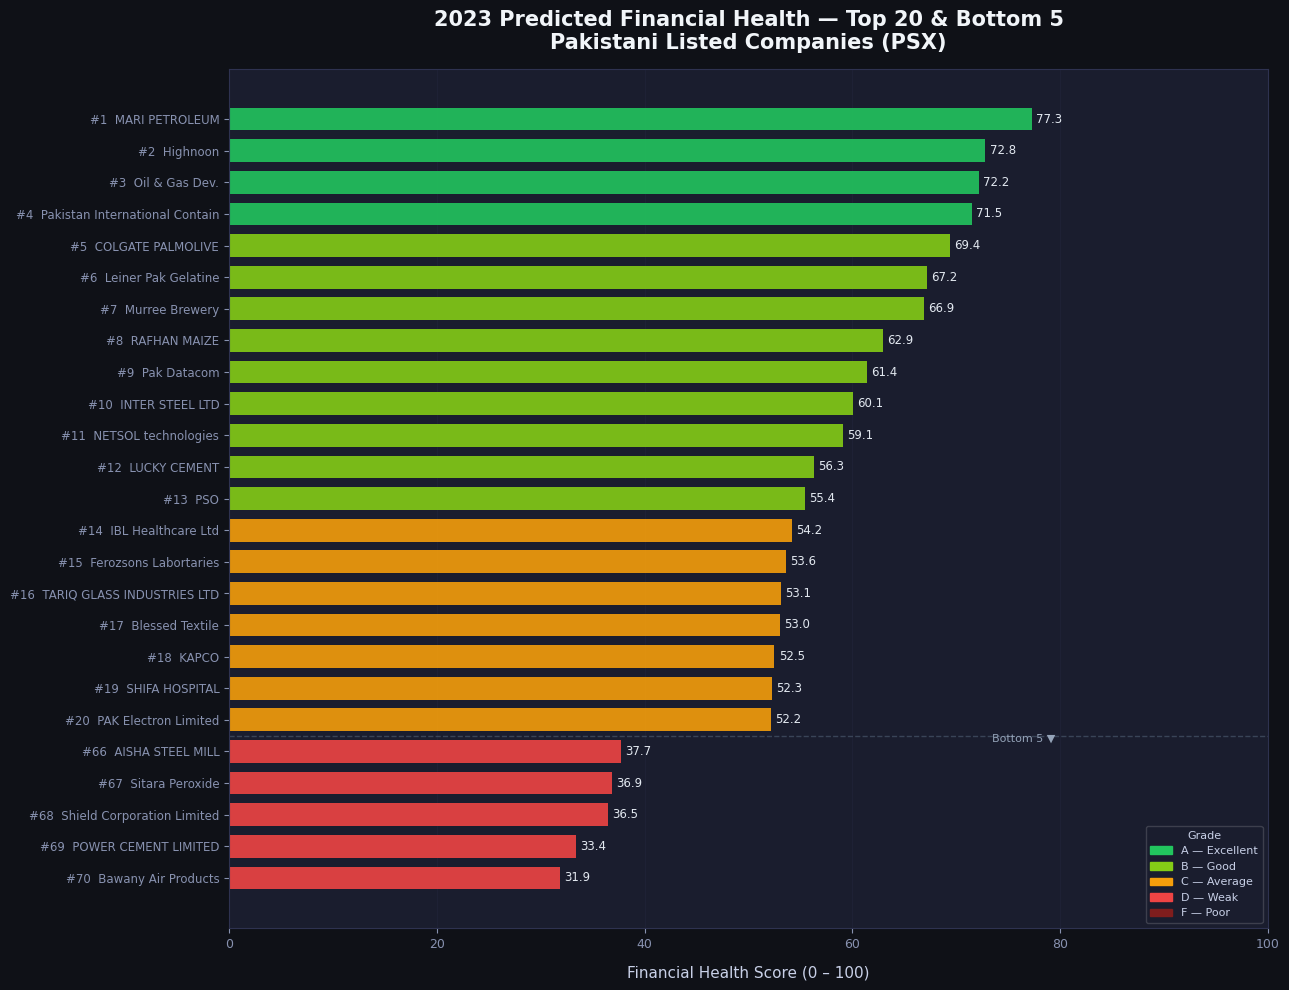

✅ Saved → viz1_health_leaderboard.png


In [16]:
# ════════════════════════════════════════════════════════════════════
# VIZ 1 — HEALTH SCORE LEADERBOARD (Top 20 + bottom 5)
# ════════════════════════════════════════════════════════════════════

top20   = health_df.head(20).copy()
bottom5 = health_df.tail(5).copy()
show    = pd.concat([top20, bottom5]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0f1117')

y_pos = np.arange(len(show))

# Bar colours by grade
bar_colors = [GRADE_COLORS.get(g, '#64748b') for g in show['grade']]

bars = ax.barh(y_pos, show['health_score'], color=bar_colors,
               edgecolor='none', height=0.72, alpha=0.9)

# Score labels
for bar, score, rank in zip(bars, show['health_score'], show['rank']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', ha='left',
            fontsize=8.5, color='#e2e8f0')

# Separator between top 20 and bottom 5
ax.axhline(y=19.5, color='#475569', linewidth=1, linestyle='--', alpha=0.7)
ax.text(ax.get_xlim()[1] * 0.98, 19.7, 'Bottom 5 ▼',
        ha='right', fontsize=8, color='#94a3b8')

# Y-axis labels: rank + company
labels = [f'#{int(r)}  {co[:30]}' for r, co in zip(show['rank'], show['company'])]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel('Financial Health Score (0 – 100)', labelpad=10)
ax.set_xlim(0, 100)
ax.set_title('2023 Predicted Financial Health — Top 20 & Bottom 5\n'
             'Pakistani Listed Companies (PSX)', fontsize=15,
             fontweight='bold', color='#f1f5f9', pad=14)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Legend
legend_patches = [mpatches.Patch(color=c, label=g)
                  for g, c in GRADE_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right',
          framealpha=0.2, fontsize=8, title='Grade',
          title_fontsize=8, labelcolor='#c8d0e7')

plt.tight_layout()
plt.savefig('viz1_health_leaderboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz1_health_leaderboard.png')

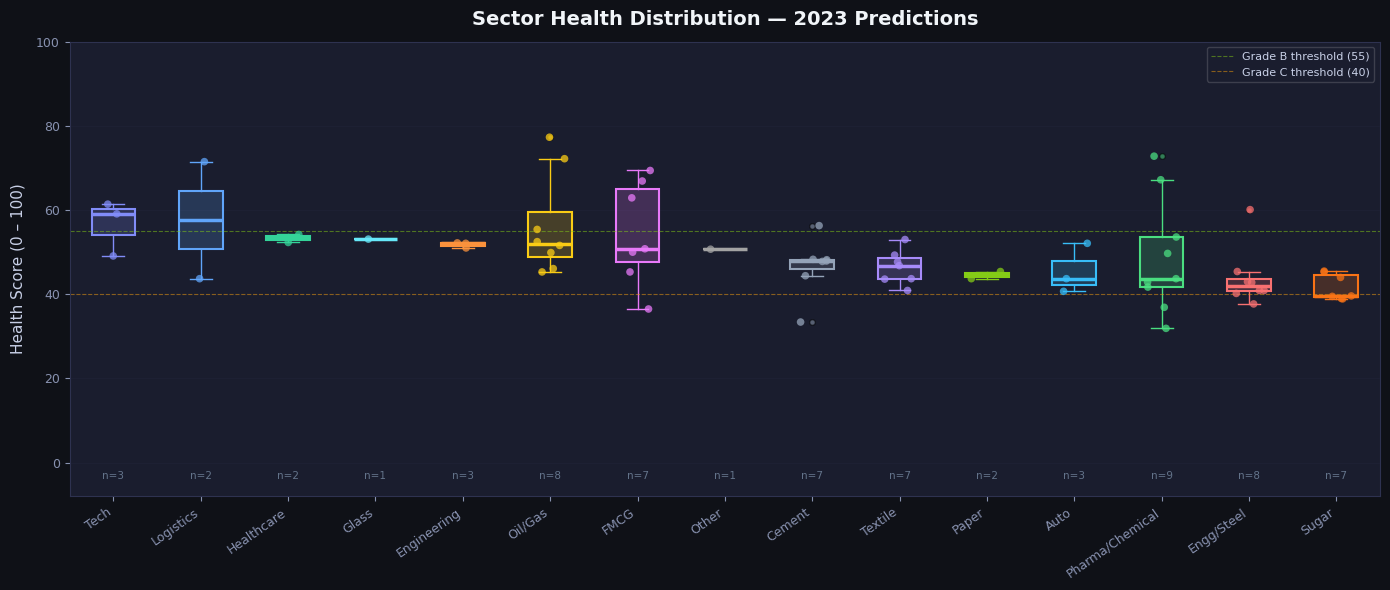

✅ Saved → viz2_sector_comparison.png


In [17]:
# ════════════════════════════════════════════════════════════════════
# VIZ 2 — SECTOR HEALTH COMPARISON (box + jitter)
# ════════════════════════════════════════════════════════════════════

sector_order = (health_df.groupby('sector')['health_score']
                         .median()
                         .sort_values(ascending=False)
                         .index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

for i, sec in enumerate(sector_order):
    vals = health_df[health_df['sector'] == sec]['health_score'].values
    color = SECTOR_COLORS.get(sec, '#64748b')

    # Box
    bp = ax.boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=color + '33', edgecolor=color, linewidth=1.5),
                    medianprops=dict(color=color, linewidth=2.5),
                    whiskerprops=dict(color=color, linewidth=1),
                    capprops=dict(color=color, linewidth=1),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                   markersize=4, alpha=0.5))

    # Jitter scatter
    x_jitter = np.random.uniform(-0.18, 0.18, size=len(vals))
    ax.scatter(i + x_jitter, vals, color=color, alpha=0.75,
               s=30, zorder=3, edgecolors='none')

    # Count label
    ax.text(i, -4, f'n={len(vals)}', ha='center', fontsize=7.5,
            color='#64748b')

ax.set_xticks(range(len(sector_order)))
ax.set_xticklabels(sector_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Health Score (0 – 100)', labelpad=8)
ax.set_ylim(-8, 100)
ax.set_title('Sector Health Distribution — 2023 Predictions',
             fontsize=14, fontweight='bold', color='#f1f5f9', pad=12)
ax.axhline(55, color='#84cc16', linewidth=0.8, linestyle='--', alpha=0.5,
           label='Grade B threshold (55)')
ax.axhline(40, color='#f59e0b', linewidth=0.8, linestyle='--', alpha=0.5,
           label='Grade C threshold (40)')
ax.legend(fontsize=8, framealpha=0.2, labelcolor='#c8d0e7')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz2_sector_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz2_sector_comparison.png')

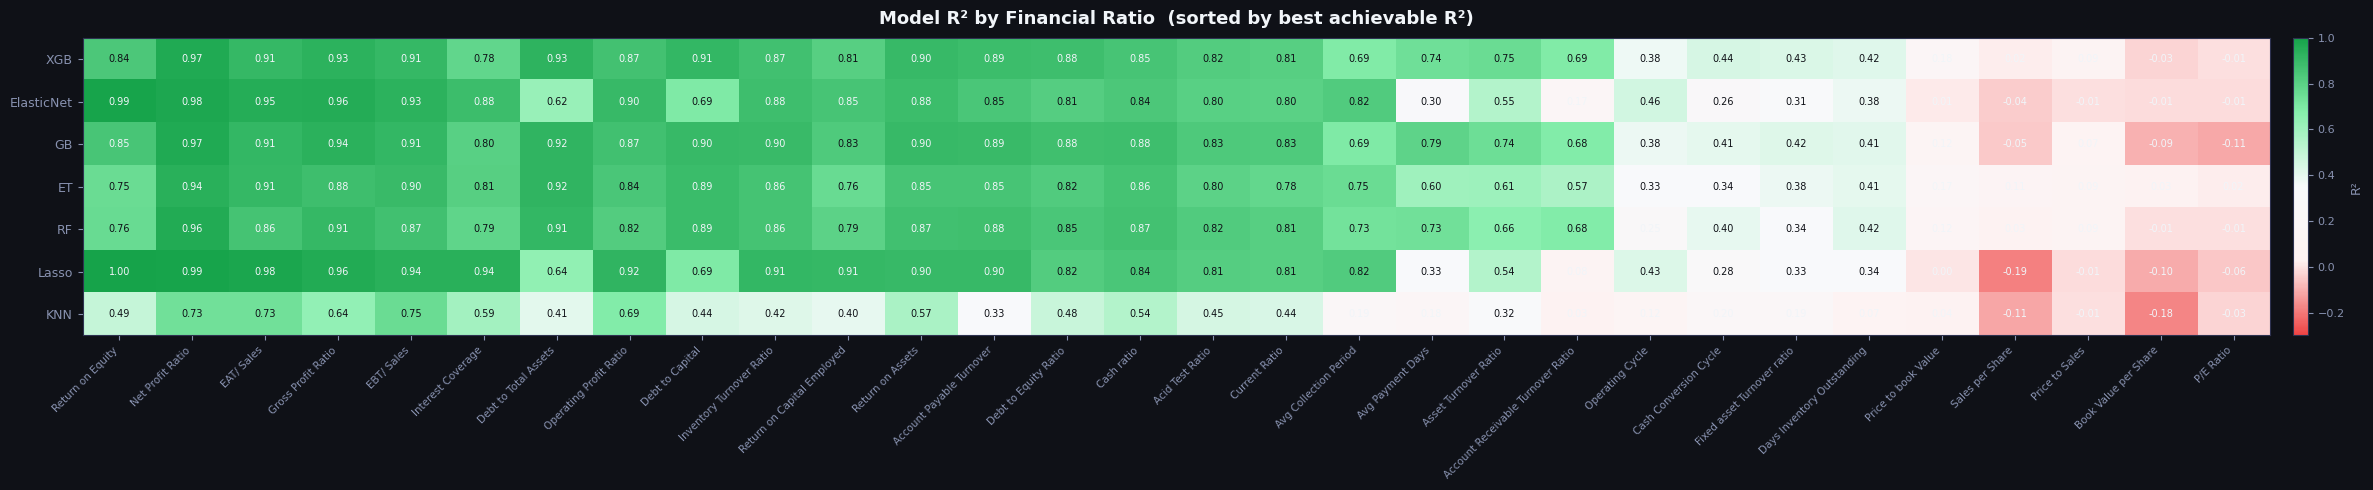

✅ Saved → viz3_model_r2_heatmap.png


In [18]:
# ════════════════════════════════════════════════════════════════════
# VIZ 3 — MODEL PERFORMANCE: R² per ratio (heatmap)
# ════════════════════════════════════════════════════════════════════

# Build model × ratio R² table
# model_r2_table is dict: model -> {ratio_col: r2}
model_names = list(model_zoo.keys())   # from Cell 9
ratio_labels = [k.replace('ratio_', '') for k in ratio_cols]

r2_matrix = np.array([
    [model_r2_table[m].get(col, np.nan) for col in ratio_cols]
    for m in model_names
])

# Sort ratios by best achieved R²
best_per_ratio = np.nanmax(r2_matrix, axis=0)
sort_idx = np.argsort(-best_per_ratio)
r2_matrix_sorted = r2_matrix[:, sort_idx]
ratio_labels_sorted = [ratio_labels[i] for i in sort_idx]

# Custom diverging colormap: red (negative) → white (zero) → green (1)
cmap = LinearSegmentedColormap.from_list(
    'rg', ['#ef4444', '#fef2f2', '#f8fafc', '#86efac', '#16a34a'])

fig, ax = plt.subplots(figsize=(max(14, len(ratio_labels_sorted) * 0.8), 5))
fig.patch.set_facecolor('#0f1117')

im = ax.imshow(r2_matrix_sorted, aspect='auto', cmap=cmap,
               vmin=-0.3, vmax=1.0)

# Annotate cells
for row in range(len(model_names)):
    for col in range(len(ratio_labels_sorted)):
        val = r2_matrix_sorted[row, col]
        if not np.isnan(val):
            txt_color = '#0f1117' if 0.25 < val < 0.85 else '#f1f5f9'
            ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color=txt_color)

ax.set_xticks(range(len(ratio_labels_sorted)))
ax.set_xticklabels(ratio_labels_sorted, rotation=45, ha='right', fontsize=7.5)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=9)
ax.set_title('Model R² by Financial Ratio  (sorted by best achievable R²)',
             fontsize=13, fontweight='bold', color='#f1f5f9', pad=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cbar.ax.tick_params(labelsize=8, colors='#8892b0')
cbar.set_label('R²', color='#8892b0', fontsize=9)

plt.tight_layout()
plt.savefig('viz3_model_r2_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz3_model_r2_heatmap.png')

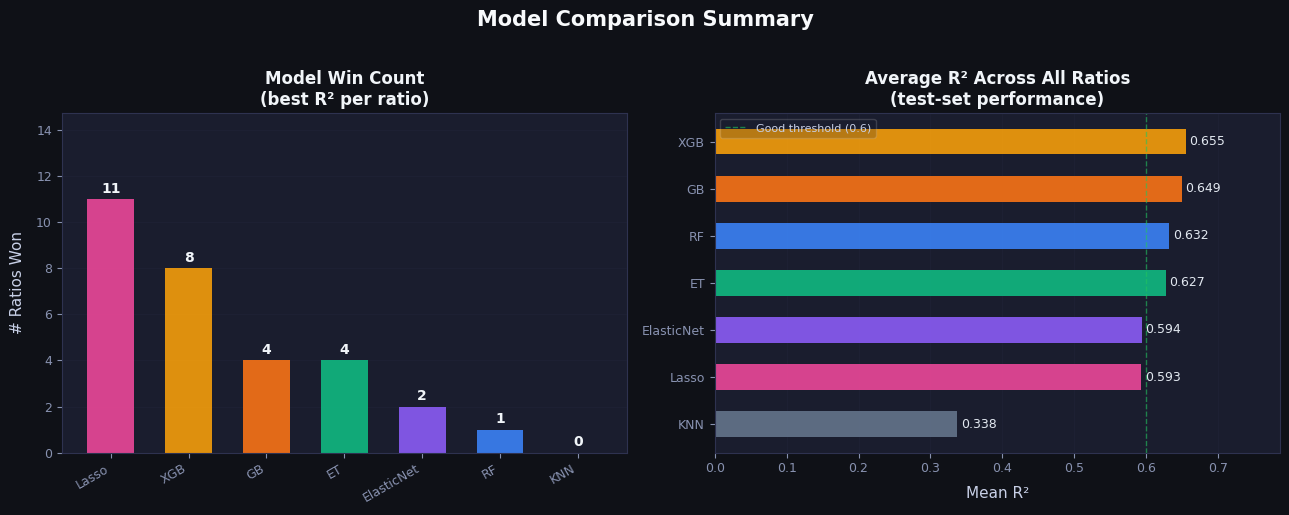

✅ Saved → viz4_model_comparison.png


In [19]:
# ════════════════════════════════════════════════════════════════════
# VIZ 4 — MODEL WIN COUNT + AVERAGE R² (dual panel)
# ════════════════════════════════════════════════════════════════════

from collections import Counter

wins     = Counter(per_ratio_model.values())
avg_r2   = {m: np.mean(list(model_r2_table[m].values()))
            for m in model_names}

# Sort by wins
m_sorted = sorted(model_names, key=lambda x: -wins.get(x, 0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

# ── Panel A: Win count ────────────────────────────────────────────
colors_sorted = [MODEL_COLORS[m] for m in m_sorted]
win_vals      = [wins.get(m, 0) for m in m_sorted]

bars1 = ax1.bar(m_sorted, win_vals, color=colors_sorted,
                edgecolor='none', width=0.6, alpha=0.9)
for bar, val in zip(bars1, win_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             str(val), ha='center', va='bottom', fontsize=10,
             fontweight='bold', color='#f1f5f9')

ax1.set_title('Model Win Count\n(best R² per ratio)', fontsize=12,
              fontweight='bold', color='#f1f5f9')
ax1.set_ylabel('# Ratios Won', labelpad=8)
ax1.set_ylim(0, max(win_vals) * 1.25 + 1)
ax1.set_xticklabels(m_sorted, rotation=30, ha='right')
ax1.grid(axis='y', alpha=0.25)
ax1.set_axisbelow(True)

# ── Panel B: Average R² (all ratios, all CV folds) ────────────────
m_sorted_r2 = sorted(model_names, key=lambda x: -avg_r2.get(x, 0))
r2_vals      = [avg_r2[m] for m in m_sorted_r2]
colors_r2    = [MODEL_COLORS[m] for m in m_sorted_r2]

bars2 = ax2.barh(m_sorted_r2, r2_vals, color=colors_r2,
                 edgecolor='none', height=0.55, alpha=0.9)
for bar, val in zip(bars2, r2_vals):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left', fontsize=9,
             color='#e2e8f0')

ax2.set_title('Average R² Across All Ratios\n(test-set performance)', fontsize=12,
              fontweight='bold', color='#f1f5f9')
ax2.set_xlabel('Mean R²', labelpad=8)
ax2.set_xlim(0, max(r2_vals) * 1.2)
ax2.invert_yaxis()
ax2.axvline(0.6, color='#22c55e', linewidth=1, linestyle='--',
            alpha=0.6, label='Good threshold (0.6)')
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='#c8d0e7')
ax2.grid(axis='x', alpha=0.25)
ax2.set_axisbelow(True)

plt.suptitle('Model Comparison Summary', fontsize=15,
             fontweight='bold', color='#f8fafc', y=1.02)
plt.tight_layout()
plt.savefig('viz4_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz4_model_comparison.png')

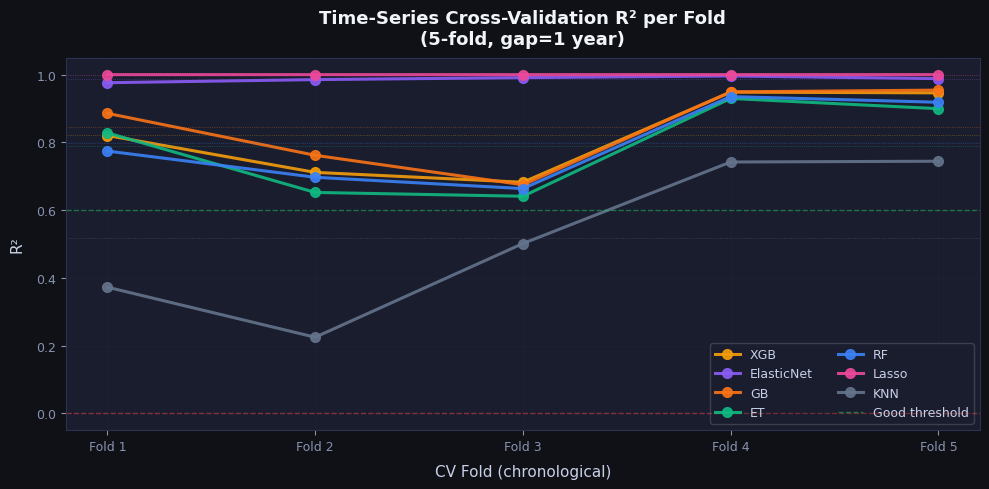

✅ Saved → viz5_cv_folds.png


In [20]:
# ════════════════════════════════════════════════════════════════════
# VIZ 5 — TIME SERIES CV: fold-by-fold R² per model
# ════════════════════════════════════════════════════════════════════

# cv_r2_all: dict model -> list of 5 fold R²s
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')

folds = [f'Fold {i+1}' for i in range(5)]

for mname, scores in cv_r2_all.items():
    color = MODEL_COLORS.get(mname, '#94a3b8')
    ax.plot(folds, scores, marker='o', linewidth=2.2,
            markersize=7, label=mname, color=color, alpha=0.9)
    # Confidence band (just show the avg)
    avg = np.mean(scores)
    ax.axhline(avg, color=color, linewidth=0.6, linestyle=':', alpha=0.45)

ax.axhline(0, color='#ef4444', linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(0.6, color='#22c55e', linewidth=1, linestyle='--', alpha=0.5,
           label='Good threshold')
ax.set_title('Time-Series Cross-Validation R² per Fold\n'
             '(5-fold, gap=1 year)', fontsize=13,
             fontweight='bold', color='#f1f5f9', pad=10)
ax.set_ylabel('R²', labelpad=8)
ax.set_xlabel('CV Fold (chronological)', labelpad=8)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='#c8d0e7',
          ncol=2, loc='lower right')
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz5_cv_folds.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz5_cv_folds.png')

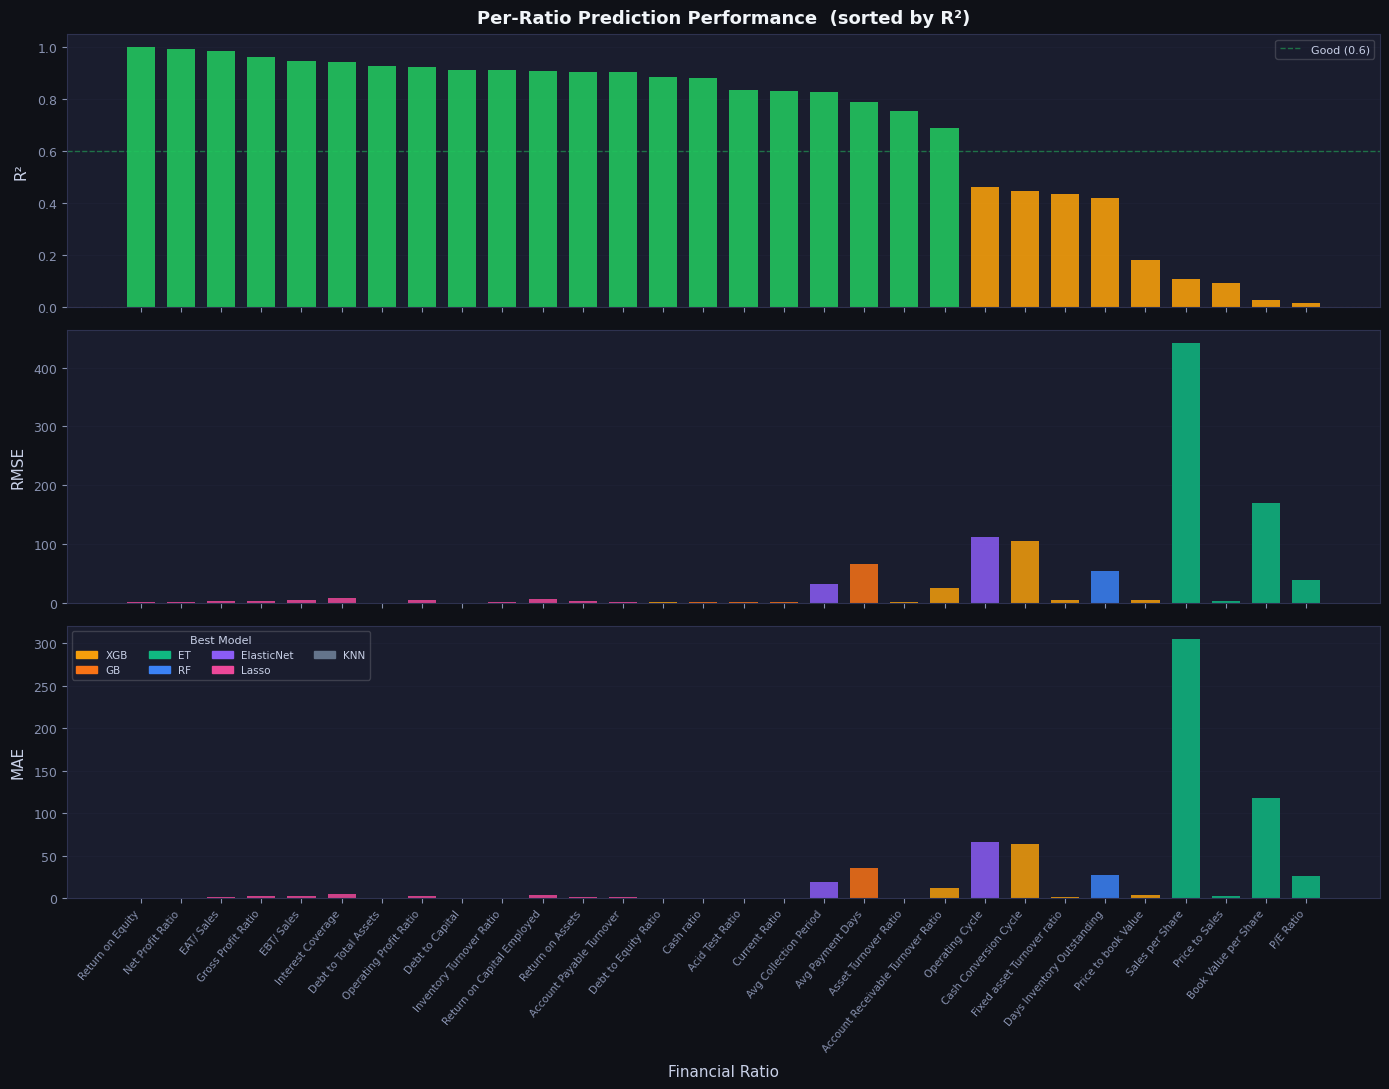

✅ Saved → viz6_ratio_performance.png


In [21]:
# ════════════════════════════════════════════════════════════════════
# VIZ 6 — RATIO PREDICTION QUALITY (R², RMSE, MAE bar chart)
# ════════════════════════════════════════════════════════════════════

# Build sorted performance dataframe
perf = pd.DataFrame({
    'ratio':      [k.replace('ratio_', '') for k in per_ratio_r2],
    'R2':         list(per_ratio_r2.values()),
    'RMSE':       list(per_ratio_rmse.values()),
    'MAE':        list(per_ratio_mae.values()),
    'best_model': list(per_ratio_model.values()),
}).sort_values('R2', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.patch.set_facecolor('#0f1117')

x = np.arange(len(perf))

# ── R² ────────────────────────────────────────────────────────────
bar_colors = ['#22c55e' if v > 0.6 else ('#f59e0b' if v > 0 else '#ef4444')
              for v in perf['R2']]
axes[0].bar(x, perf['R2'], color=bar_colors, edgecolor='none',
            width=0.7, alpha=0.9)
axes[0].axhline(0.6, color='#22c55e', linewidth=1, linestyle='--',
                alpha=0.5, label='Good (0.6)')
axes[0].axhline(0, color='#ef4444', linewidth=0.8, linestyle='--', alpha=0.4)
axes[0].set_ylabel('R²', labelpad=6)
axes[0].set_title('Per-Ratio Prediction Performance  (sorted by R²)',
                  fontsize=13, fontweight='bold', color='#f1f5f9', pad=8)
axes[0].legend(fontsize=8, framealpha=0.2, labelcolor='#c8d0e7')
axes[0].grid(axis='y', alpha=0.25)

# ── RMSE ──────────────────────────────────────────────────────────
axes[1].bar(x, perf['RMSE'],
            color=[MODEL_COLORS.get(m, '#64748b') for m in perf['best_model']],
            edgecolor='none', width=0.7, alpha=0.85)
axes[1].set_ylabel('RMSE', labelpad=6)
axes[1].grid(axis='y', alpha=0.25)

# ── MAE ───────────────────────────────────────────────────────────
axes[2].bar(x, perf['MAE'],
            color=[MODEL_COLORS.get(m, '#64748b') for m in perf['best_model']],
            edgecolor='none', width=0.7, alpha=0.85)
axes[2].set_ylabel('MAE', labelpad=6)
axes[2].set_xlabel('Financial Ratio', labelpad=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(perf['ratio'], rotation=50, ha='right', fontsize=7.5)
axes[2].grid(axis='y', alpha=0.25)

# Colour model legend on last panel
model_patches = [mpatches.Patch(color=c, label=m)
                 for m, c in MODEL_COLORS.items()]
axes[2].legend(handles=model_patches, title='Best Model',
               fontsize=7.5, title_fontsize=8,
               framealpha=0.2, labelcolor='#c8d0e7', ncol=4)

for ax in axes:
    ax.set_axisbelow(True)
    ax.set_facecolor('#1a1d2e')

plt.tight_layout()
plt.savefig('viz6_ratio_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz6_ratio_performance.png')

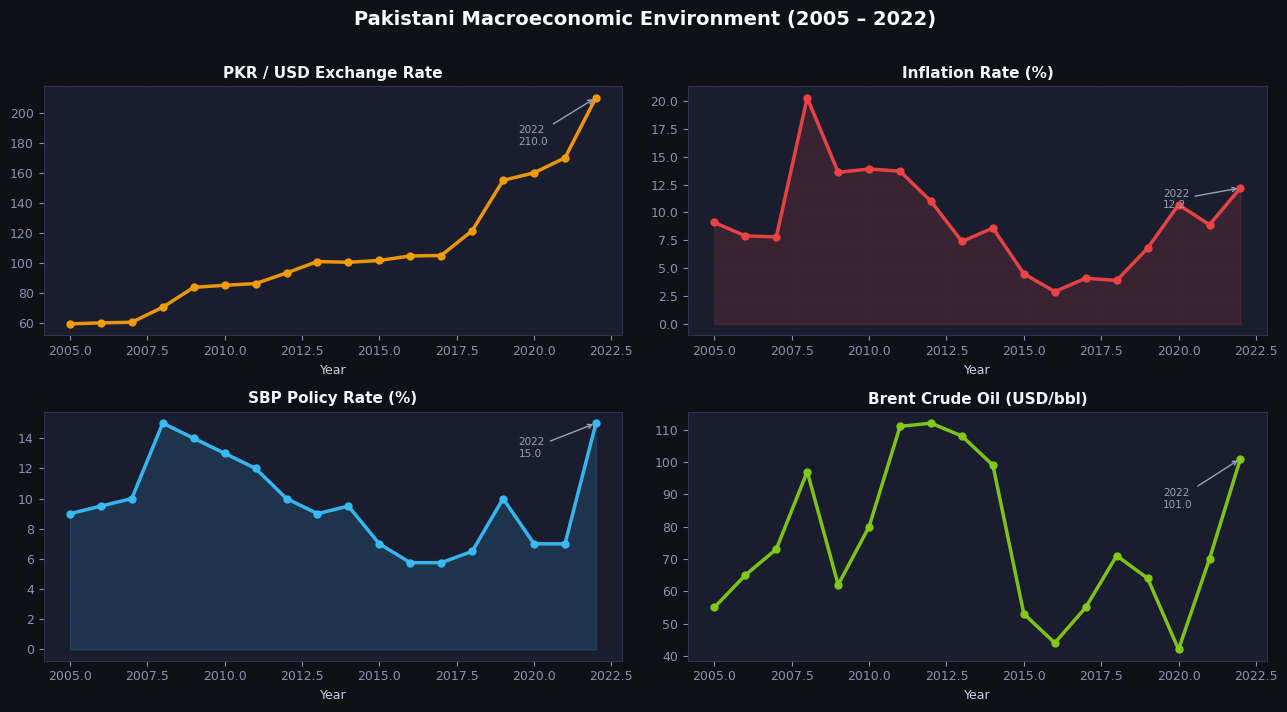

✅ Saved → viz7_macro_trends.png


In [22]:
# ════════════════════════════════════════════════════════════════════
# VIZ 7 — MACRO TREND (PKR/USD, Inflation, Policy Rate, Oil)
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

macro_series = [
    ('pkr_usd',     'PKR / USD Exchange Rate',  '#f59e0b', False),
    ('inflation',   'Inflation Rate (%)',        '#ef4444', True),
    ('policy_rate', 'SBP Policy Rate (%)',       '#38bdf8', True),
    ('oil_brent',   'Brent Crude Oil (USD/bbl)', '#84cc16', False),
]

for ax, (col, title, color, fill) in zip(axes, macro_series):
    ax.set_facecolor('#1a1d2e')
    ax.plot(macro_df['year'], macro_df[col], color=color,
            linewidth=2.5, marker='o', markersize=5, alpha=0.95)
    if fill:
        ax.fill_between(macro_df['year'], macro_df[col], alpha=0.15, color=color)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#f1f5f9', pad=6)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    # Annotate 2022 (crisis year)
    y_2022 = macro_df[macro_df['year'] == 2022][col].values
    if len(y_2022):
        ax.annotate(f'2022\n{y_2022[0]:.1f}',
                    xy=(2022, y_2022[0]),
                    xytext=(2019.5, y_2022[0] * 0.85),
                    arrowprops=dict(arrowstyle='->', color='#94a3b8', lw=1),
                    fontsize=7.5, color='#94a3b8')

fig.suptitle('Pakistani Macroeconomic Environment (2005 – 2022)',
             fontsize=14, fontweight='bold', color='#f8fafc', y=1.01)
plt.tight_layout()
plt.savefig('viz7_macro_trends.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz7_macro_trends.png')

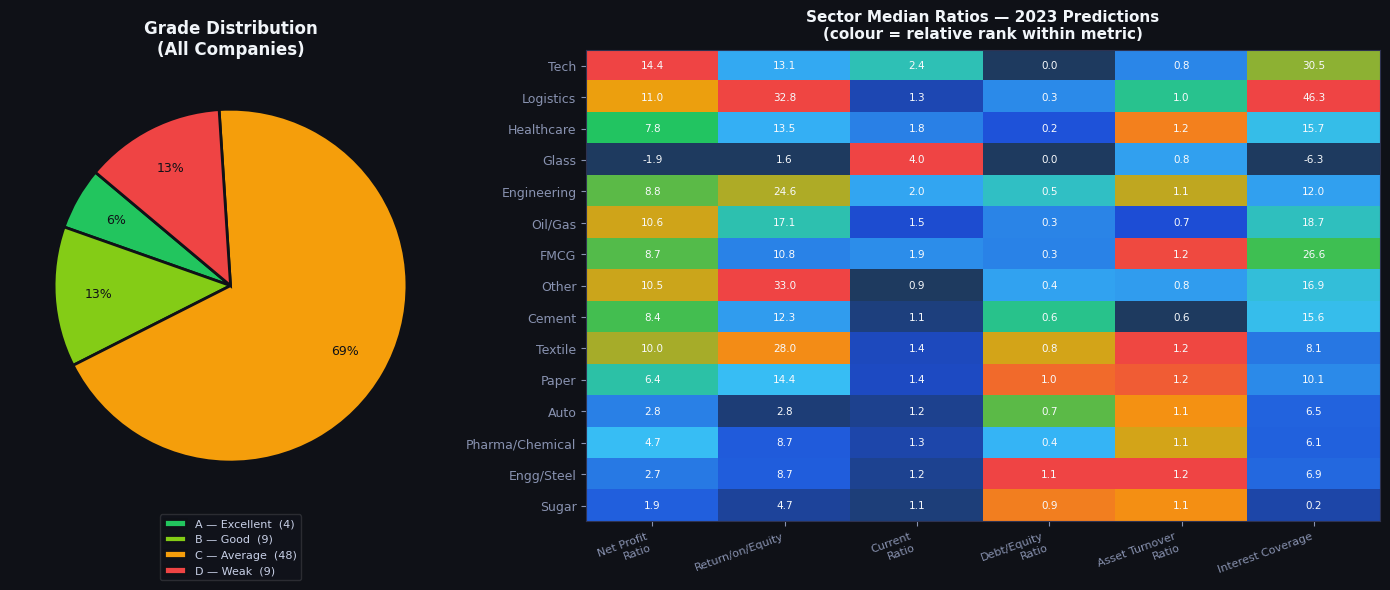

✅ Saved → viz8_grade_dist_sector_heatmap.png


In [23]:
# ════════════════════════════════════════════════════════════════════
# VIZ 8 — GRADE DISTRIBUTION PIE + SECTOR HEATMAP (2-panel)
# ════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1, 1.8]})
fig.patch.set_facecolor('#0f1117')

# ── Panel A: Grade pie ────────────────────────────────────────────
ax1.set_facecolor('#1a1d2e')
grade_counts = health_df['grade'].value_counts()
grade_order  = ['A — Excellent', 'B — Good', 'C — Average',
                'D — Weak', 'F — Poor']
grade_order  = [g for g in grade_order if g in grade_counts.index]
counts = [grade_counts[g] for g in grade_order]
colors = [GRADE_COLORS[g] for g in grade_order]

wedges, texts, autotexts = ax1.pie(
    counts, labels=None, colors=colors,
    autopct='%1.0f%%', startangle=140,
    pctdistance=0.75, wedgeprops=dict(edgecolor='#0f1117', linewidth=2))
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('#0f1117')

ax1.legend(wedges, [f'{g}  ({c})' for g, c in zip(grade_order, counts)],
           loc='lower center', fontsize=8, framealpha=0.15,
           labelcolor='#c8d0e7', bbox_to_anchor=(0.5, -0.18))
ax1.set_title('Grade Distribution\n(All Companies)', fontsize=12,
              fontweight='bold', color='#f1f5f9', pad=8)

# ── Panel B: Sector × metric heatmap ─────────────────────────────
key_metrics = ['Net Profit Ratio', 'Return on Equity', 'Current Ratio',
               'Debt to Equity Ratio', 'Asset Turnover Ratio', 'Interest Coverage']
key_metrics = [m for m in key_metrics if m in pred_df.columns]

sec_pivot = (pred_df.groupby('sector')[key_metrics]
                    .median()
                    .reindex(sector_order))

# Normalise each column to [0,1] for colour mapping
sec_norm = (sec_pivot - sec_pivot.min()) / (sec_pivot.max() - sec_pivot.min() + 1e-9)

cmap_hm = LinearSegmentedColormap.from_list(
    'heat', ['#1e3a5f', '#1d4ed8', '#38bdf8', '#22c55e', '#f59e0b', '#ef4444'])

im = ax2.imshow(sec_norm.values, aspect='auto', cmap=cmap_hm,
                vmin=0, vmax=1)
ax2.set_xticks(range(len(key_metrics)))
ax2.set_xticklabels([m.replace(' Ratio', '\nRatio').replace(' to ', '/').replace(' on ', '/on/')
                     for m in key_metrics],
                    fontsize=8, rotation=20, ha='right')
ax2.set_yticks(range(len(sec_pivot.index)))
ax2.set_yticklabels(sec_pivot.index, fontsize=9)

# Annotate with raw median values
for row_i, sector in enumerate(sec_pivot.index):
    for col_i, metric in enumerate(key_metrics):
        val = sec_pivot.loc[sector, metric]
        ax2.text(col_i, row_i, f'{val:.1f}', ha='center', va='center',
                 fontsize=7.5, color='#f8fafc')

ax2.set_title('Sector Median Ratios — 2023 Predictions\n(colour = relative rank within metric)',
              fontsize=11, fontweight='bold', color='#f1f5f9', pad=8)

plt.tight_layout()
plt.savefig('viz8_grade_dist_sector_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Saved → viz8_grade_dist_sector_heatmap.png')